In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")

In [4]:
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [5]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [6]:
df1 = df.copy()
df2 = df.copy()

In [7]:
df.head()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Months since Last Donation   576 non-null    int64
 1   Number of Donations          576 non-null    int64
 2   Total Volume Donated (c.c.)  576 non-null    int64
 3   Months since First Donation  576 non-null    int64
 4   Made Donation in March 2007  576 non-null    int64
dtypes: int64(5)
memory usage: 22.6 KB


In [9]:
df.describe()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000
mean,9.439236,5.427083,1356.770833,34.050347,0.239583
std,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.000000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,49.250000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


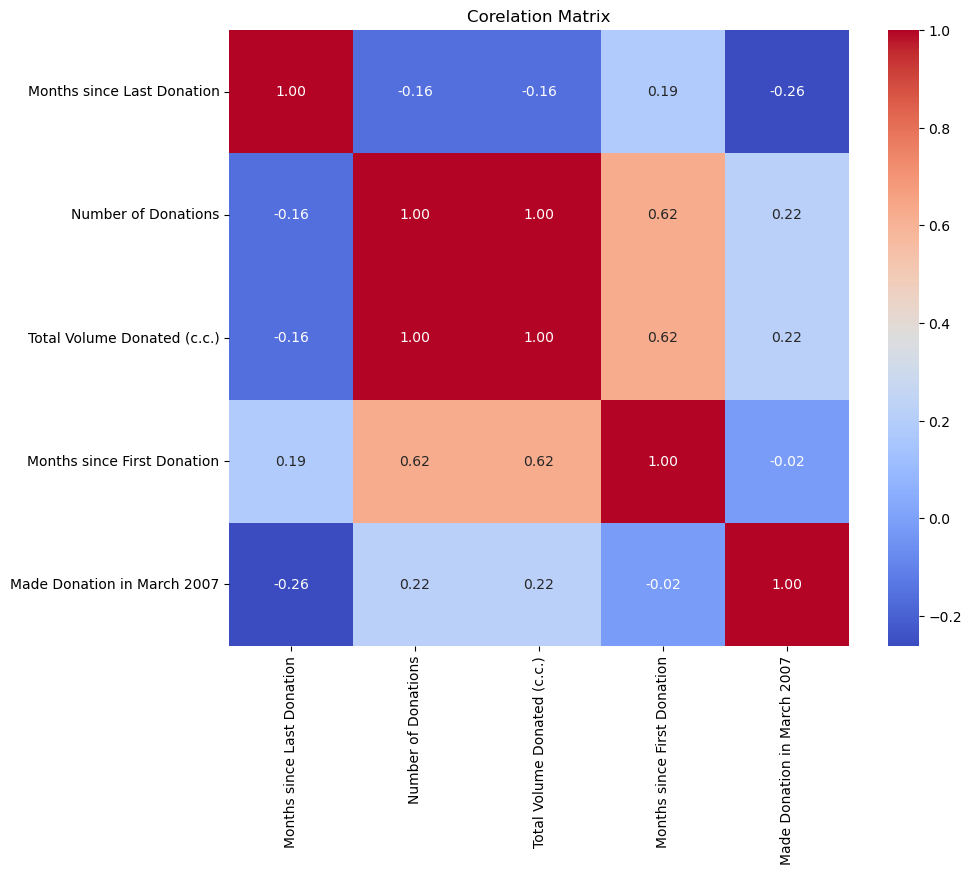

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Corelation Matrix")
plt.show()

In [11]:
df.drop("Total Volume Donated (c.c.)",axis=1,inplace=True)

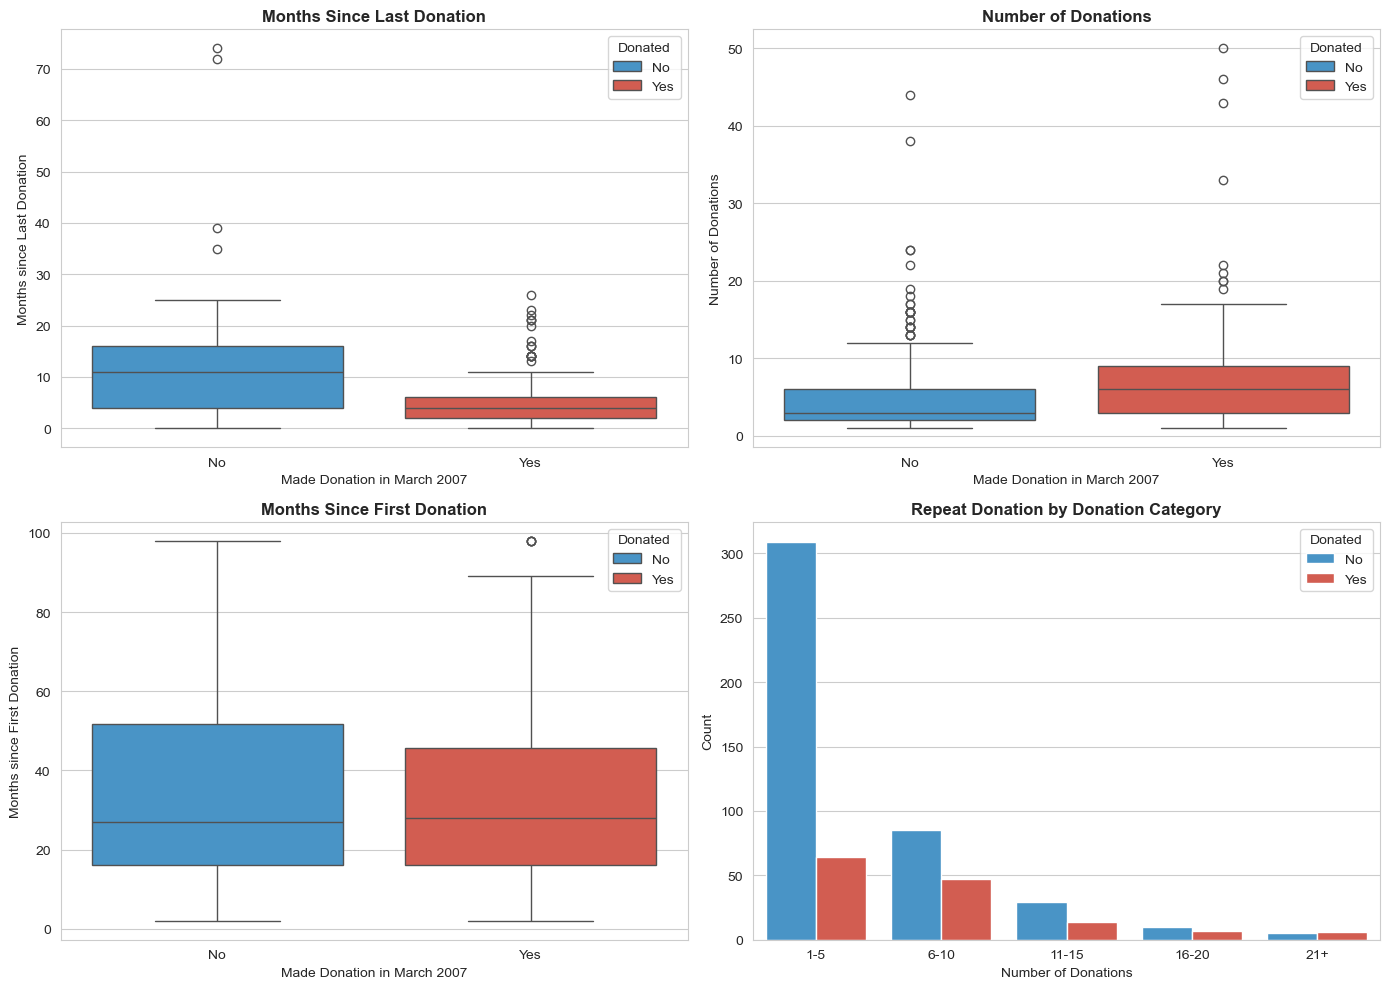

In [22]:

sns.set_style("whitegrid")
palette = ["#3498db", "#e74c3c"]  # blue=No, red=Yes

fig, axes = plt.subplots(2, 2, figsize=(14,10))  # 2 rows, 2 columns

# 1. Months since Last Donation
sns.boxplot(
    x='Made Donation in March 2007',
    y='Months since Last Donation',
    data=df,
    palette=palette,
    ax=axes[0,0]
)
axes[0,0].set_title("Months Since Last Donation", fontsize=12, weight='bold')
axes[0,0].set_xticklabels(['No', 'Yes'])
axes[0,0].legend(title='Donated', labels=['No', 'Yes'])

# 2. Number of Donations
sns.boxplot(
    x='Made Donation in March 2007',
    y='Number of Donations',
    data=df,
    palette=palette,
    ax=axes[0,1]
)
axes[0,1].set_title("Number of Donations", fontsize=12, weight='bold')
axes[0,1].set_xticklabels(['No', 'Yes'])
axes[0,1].legend(title='Donated', labels=['No', 'Yes'])

# 3. Months Since First Donation
sns.boxplot(
    x='Made Donation in March 2007',
    y='Months since First Donation',
    data=df,
    palette=palette,
    ax=axes[1,0]
)
axes[1,0].set_title("Months Since First Donation", fontsize=12, weight='bold')
axes[1,0].set_xticklabels(['No', 'Yes'])
axes[1,0].legend(title='Donated', labels=['No', 'Yes'])

# 4. Number of Donations Category
df['DonationCategory'] = pd.cut(
    df['Number of Donations'],
    bins=[0,5,10,15,20,100],
    labels=['1-5','6-10','11-15','16-20','21+']
)
sns.countplot(
    x='DonationCategory',
    hue='Made Donation in March 2007',
    data=df,
    palette=palette,
    ax=axes[1,1]
)
axes[1,1].set_title("Repeat Donation by Donation Category", fontsize=12, weight='bold')
axes[1,1].set_xlabel("Number of Donations")
axes[1,1].set_ylabel("Count")
axes[1,1].legend(title='Donated', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

Class counts after SMOTE:
 Made Donation in March 2007
0    350
1    350
Name: count, dtype: int64


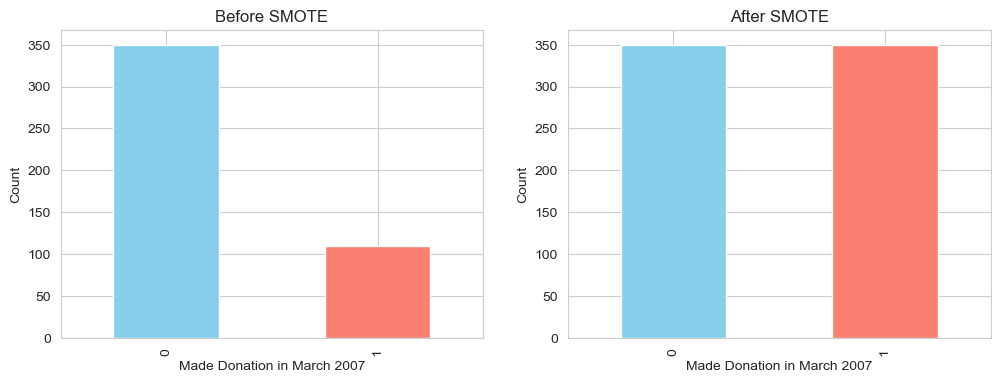

In [16]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df[['Months since Last Donation', 'Number of Donations', 'Months since First Donation']]
y = df['Made Donation in March 2007']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE on training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Show class counts after SMOTE
print("Class counts after SMOTE:\n", y_train_res.value_counts())

# Plot before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Made Donation in March 2007")
axes[0].set_ylabel("Count")

# After SMOTE
y_train_res.value_counts().plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Made Donation in March 2007")
axes[1].set_ylabel("Count")

plt.show()

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve

--- Logistic Regression ---
              precision    recall  f1-score   support

           0      0.857     0.545     0.667        88
           1      0.333     0.714     0.455        28

    accuracy                          0.586       116
   macro avg      0.595     0.630     0.561       116
weighted avg      0.731     0.586     0.615       116

ROC-AUC: 0.673
--- Decision Tree ---
              precision    recall  f1-score   support

           0      0.759     0.682     0.719        88
           1      0.243     0.321     0.277        28

    accuracy                          0.595       116
   macro avg      0.501     0.502     0.498       116
weighted avg      0.635     0.595     0.612       116

ROC-AUC: 0.527
--- Random Forest ---
              precision    recall  f1-score   support

           0      0.807     0.807     0.807        88
           1      0.393     0.393     0.393        28

    accuracy                          0.707       116
   macro avg      0.600   

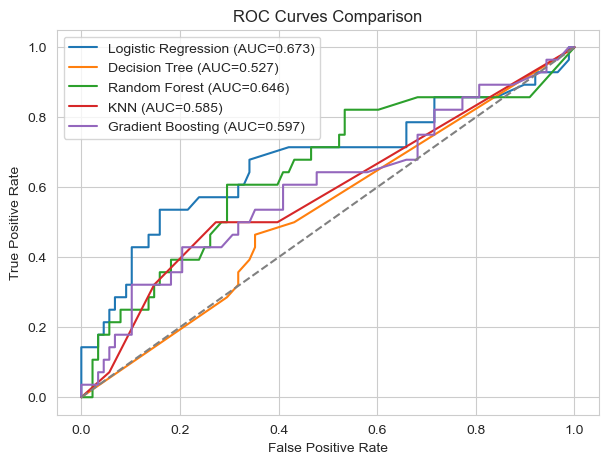

In [24]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
plt.figure(figsize=(7,5))

for name, model in models.items():
    # Train on SMOTE-balanced training set
    model.fit(X_train_res, y_train_res)

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    # Classification report
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, digits=3))

    # ROC-AUC
    if y_proba is not None:
        auc = round(roc_auc_score(y_test, y_proba),3)
        print("ROC-AUC:", auc)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc})")

    results[name] = {"model": model, "y_pred": y_pred, "y_proba": y_proba}

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import f1_score, precision_recall_curve

def tune_threshold(y_true, y_proba, step=0.01):
    best_f1, best_thr = 0, 0.5
    for thr in np.arange(0.1, 0.9, step):
        y_pred_thr = (y_proba >= thr).astype(int)
        f1 = f1_score(y_true, y_pred_thr)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

# Example: tuning Random Forest
y_proba_rf = results['Random Forest']['y_proba']
best_thr, best_f1 = tune_threshold(y_test, y_proba_rf)
print("Best threshold for RF:", best_thr, "with F1:", round(best_f1,3))
y_pred_rf_thr = (y_proba_rf >= best_thr).astype(int)

Best threshold for RF: 0.3799999999999999 with F1: 0.479


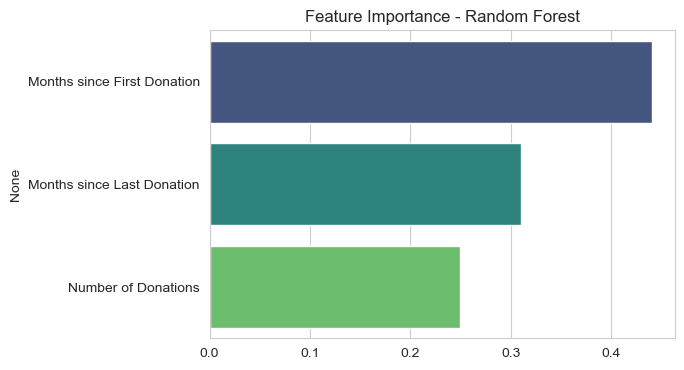

In [26]:
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.show()

In [27]:

def tune_threshold(y_true, y_proba, step=0.01):
    """
    Finds the threshold that maximizes F1-score.
    Returns best threshold and corresponding F1.
    """
    best_f1 = 0
    best_thr = 0.5
    for thr in np.arange(0.1, 0.9, step):
        y_pred = (y_proba >= thr).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1


In [28]:
# Use the already trained Logistic Regression (with SMOTE)
lr_model = results['Logistic Regression']['model']
y_proba_lr = results['Logistic Regression']['y_proba']

best_thr_lr, best_f1_lr = tune_threshold(y_test, y_proba_lr)
print("Best threshold for LR:", round(best_thr_lr,3), "→ F1:", round(best_f1_lr,3))

# Predict with new threshold
y_pred_lr_thr = (y_proba_lr >= best_thr_lr).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_thr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_thr, digits=3))

Best threshold for LR: 0.62 → F1: 0.526
Confusion Matrix:
 [[74 14]
 [13 15]]

Classification Report:
               precision    recall  f1-score   support

           0      0.851     0.841     0.846        88
           1      0.517     0.536     0.526        28

    accuracy                          0.767       116
   macro avg      0.684     0.688     0.686       116
weighted avg      0.770     0.767     0.769       116



Why Accuracy is Moderate (~76%)
High Class Imbalance:
Original data had ~76% non-donors; accuracy is biased toward the majority class.

Small Dataset:
Only 576 samples; test set has just 28 positives, making metrics sensitive.

Limited Features:
Only donation history features; other behavioral or demographic signals are missing.

SMOTE & Threshold Tuning:
Synthetic samples and adjusted threshold improved recall/F1 for repeat donors but slightly increased false positives, lowering raw accuracy.